In [1]:
import os
from fractions import Fraction
from pathlib import Path

import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt
from neuromaps.datasets import fetch_fslr
from nisc.cifti import get_cifti_surf_data
from sklearn.preprocessing import scale
from tqdm import tqdm

import yaspy
from arfcexp.video import save_video

In [2]:
import pyvista as pv

pv.start_xvfb()

In [3]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [4]:
HCP_TR = 0.72
NUM_VERTICES = 32492

project_root = Path(os.environ["PROJECT_ROOT"])
hcp_root = Path(os.environ["HCP_1200_DIR"])

visualize_raw_dir = project_root / "results/visualize_raw_hcp_timeseries"
visualize_raw_dir.mkdir(exist_ok=True)

In [5]:
surfaces = fetch_fslr()
surf_lh_path, surf_rh_path = surfaces["inflated"]
sulc_lh_path, sulc_rh_path = surfaces["sulc"]
print(surf_lh_path)
print(sulc_lh_path)

/jet/home/clane2/neuromaps-data/atlases/fsLR/tpl-fsLR_den-32k_hemi-L_inflated.surf.gii
/jet/home/clane2/neuromaps-data/atlases/fsLR/tpl-fsLR_den-32k_hemi-L_desc-sulc_midthickness.shape.gii


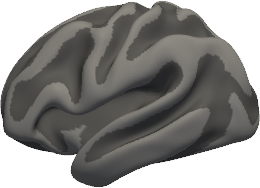

In [6]:
plotter_lh = yaspy.Plotter(surf_lh_path, hemi="lh", sulc=sulc_lh_path)
plotter_rh = yaspy.Plotter(surf_rh_path, hemi="rh", sulc=sulc_rh_path)

plotter_lh.screenshot()

In [7]:
n_subs = 4

sub_list_path = (
    project_root / "resources/subject_lists/hcp_complete_data_867_subject_list.txt"
)
subjects = np.genfromtxt(sub_list_path, dtype=str)[:n_subs]
print(subjects)

['181131' '245333' '106824' '187547']


In [8]:
pattern = "rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii"

paths = {sub: next(iter((hcp_root / sub).rglob(pattern))) for sub in subjects}
print("\n".join(map(str, paths.values())))

/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/181131/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii
/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/245333/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii
/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/106824/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii
/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/187547/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii


In [9]:
def load_cifti(path: Path) -> np.ndarray:
    """Load cifti time series data."""
    data = nib.load(path)
    data = get_cifti_surf_data(data)
    data = np.ascontiguousarray(data.T)
    return data

In [10]:
all_series = {sub: load_cifti(path) for sub, path in paths.items()}

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [11]:
for sub, data in all_series.items():
    print(sub, data.shape)

181131 (1200, 64984)
245333 (1200, 64984)
106824 (1200, 64984)
187547 (1200, 64984)


In [12]:
mean_maps = {sub: np.mean(data, axis=0) for sub, data in all_series.items()}
std_maps = {sub: np.std(data, axis=0) for sub, data in all_series.items()}

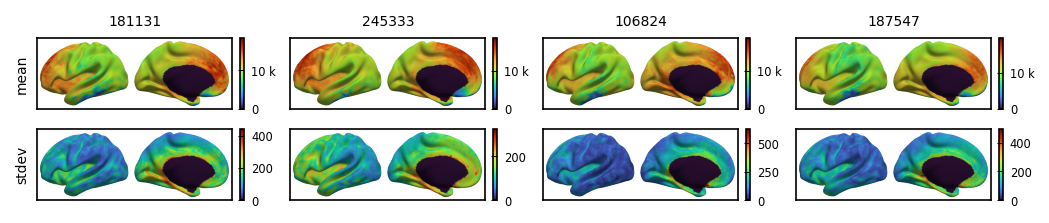

In [13]:
from matplotlib.ticker import EngFormatter

nr = 2
nc = n_subs

W, H = plotter_lh.screenshot().size
W *= 1.8

plotw = 2 * PLOTW / nc
ploth = (H / W) * plotw

f, axs = plt.subplots(nr, nc, figsize=(nc * plotw, nr * ploth), layout="constrained")

for ii, (stat, maps) in enumerate(zip(["mean", "stdev"], [mean_maps, std_maps])):
    for jj, sub in enumerate(subjects):
        ax = axs[ii, jj]
        plt.sca(ax)

        map_lh, _ = np.split(maps[sub], 2)

        plotter_lh.clear()
        overlay = plotter_lh.overlay(map_lh, cmap="turbo")

        img = yaspy.montage(
            [plotter_lh.screenshot("lateral"), plotter_lh.screenshot("medial")],
            pad=8,
        )
        plt.imshow(img)

        plt.xticks([])
        plt.yticks([])

        cbar = plt.colorbar(overlay, ax=ax, fraction=0.046, pad=0.04)
        cbar.long_axis.set_major_formatter(EngFormatter())
        cbar.ax.tick_params(labelsize="x-small")

        if ii == 0:
            plt.title(sub, fontsize="small")
        if jj == 0:
            plt.ylabel(stat, fontsize="small")

plt.savefig(visualize_raw_dir / f"hcp_1200_rfmri_mean_stdev_maps.{FORMAT}")

In [14]:
def generate_overlay_frames(
    series: np.ndarray,
    n_frames: int = 160,
    stride: int = 3,
    vmin: float = 0.0,
    vmax: float = 20000.0,
):
    for ii in tqdm(range(n_frames)):
        plotter_lh.clear()
        plotter_rh.clear()

        frame = series[stride * ii]
        frame_lh, frame_rh = np.split(frame, 2)

        plotter_lh.overlay(frame_lh, cmap="turbo", vmin=vmin, vmax=vmax)
        plotter_rh.overlay(frame_rh, cmap="turbo", vmin=vmin, vmax=vmax)

        img = yaspy.montage(
            [
                [
                    plotter_lh.screenshot("lateral", color="black"),
                    plotter_rh.screenshot("lateral", color="black"),
                ],
                [
                    plotter_lh.screenshot("medial", color="black"),
                    plotter_rh.screenshot("medial", color="black"),
                ],
            ],
            pad=8,
            shareh=True,
        )
        yield img

In [15]:
stride = 3
n_frames = 100
fps = Fraction(int(100 * 4 / (HCP_TR * stride)), 100)
vmin = 0
vmax = 20000

for sub in subjects:
    save_video(
        visualize_raw_dir / f"hcp_1200_rfmri_{sub}_raw.mp4",
        generate_overlay_frames(
            all_series[sub],
            n_frames=n_frames,
            stride=stride,
            vmin=vmin,
            vmax=vmax,
        ),
        fps=fps,
    )

  0%|                                                                  | 0/100 [00:00<?, ?it/s]

  1%|▌                                                         | 1/100 [00:00<00:19,  5.00it/s]

  2%|█▏                                                        | 2/100 [00:00<00:16,  6.04it/s]

  3%|█▋                                                        | 3/100 [00:00<00:14,  6.65it/s]

  4%|██▎                                                       | 4/100 [00:00<00:13,  6.86it/s]

...

 ... (more hidden) ...

 ... (more hidden) ...

 ... (more hidden) ...

 ... (more hidden) ...

 ... (more hidden) ...

### Standard scaled time series

In [16]:
scaled_series = {sub: scale(series) for sub, series in all_series.items()}

In [17]:
vmin = -2.5
vmax = 2.5

for sub in subjects:
    save_video(
        visualize_raw_dir / f"hcp_1200_rfmri_{sub}_scaled.mp4",
        generate_overlay_frames(
            scaled_series[sub],
            n_frames=n_frames,
            stride=stride,
            vmin=vmin,
            vmax=vmax,
        ),
        fps=fps,
    )

 ... (more hidden) ...

 ... (more hidden) ...

 ... (more hidden) ...

 ... (more hidden) ...

 ... (more hidden) ...

...

 97%|███████████████████████████████████████████████████████▎ | 97/100 [00:13<00:00,  7.14it/s]

 98%|███████████████████████████████████████████████████████▊ | 98/100 [00:13<00:00,  7.18it/s]

 99%|████████████████████████████████████████████████████████▍| 99/100 [00:13<00:00,  7.15it/s]

100%|████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.20it/s]

100%|████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.18it/s]